# Stanford Cars — Exploratory Data Analysis

In [6]:
import sys
sys.path.insert(0, "../entrypoint")

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
from load import train_ds, val_ds, test_ds

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/504M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/test-00000-of-00002.parquet:   0%|          | 0.00/513M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/474M [00:00<?, ?B/s]

...

Generating jpeg_compression split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/8041 [00:00<?, ? examples/s]

train dataset length: 11329, expected is 11,330
validate dataset lenght: 2428, expected is 2,428
test dataset length: 2428, expected is 2,428


## 1. Basic Stats

In [7]:
full_ds = [train_ds, val_ds, test_ds]
split_names = ["Train", "Val", "Test"]

for name, ds in zip(split_names, full_ds):
    print(f"{name}: {len(ds)} samples")

print(f"\nTotal: {sum(len(d) for d in full_ds)} samples")
print(f"Number of classes: {len(set(train_ds['label']))}")

# Check for grayscale images
gray_count = sum(1 for s in train_ds if np.array(s["image"]).ndim == 2)
print(f"\nGrayscale images in train set: {gray_count}")

Train: 11329 samples
Val: 2428 samples
Test: 2428 samples

Total: 16185 samples
Number of classes: 196

Grayscale images in train set: 25


## 2. Image Size Distribution

Width  — min: 78, max: 7800, mean: 702
Height — min: 41, max: 5400, mean: 484


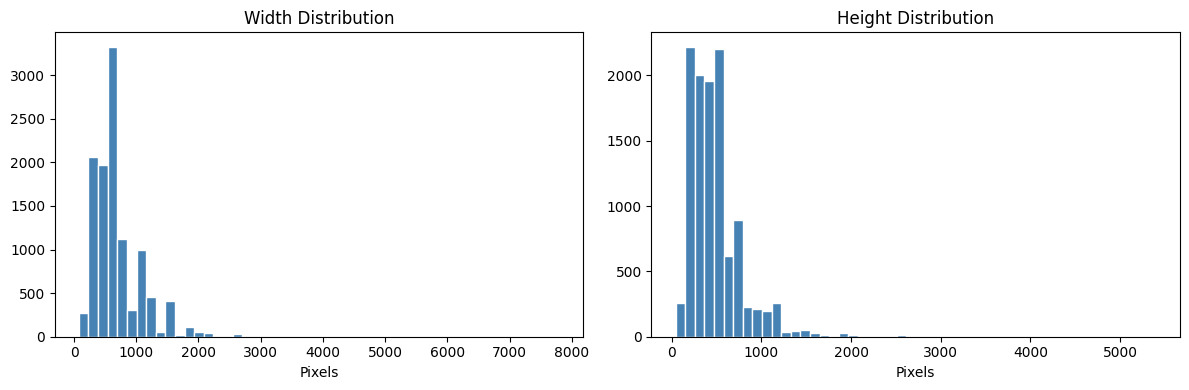

In [8]:
widths, heights = [], []
for sample in train_ds:
    img = np.array(sample["image"])
    if img.ndim == 2:
        h, w = img.shape
    else:
        h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Pixels")
axes[1].hist(heights, bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Pixels")
plt.tight_layout()
plt.show()

## 3. Class Distribution

Samples per class — min: 26, max: 95, mean: 57.8


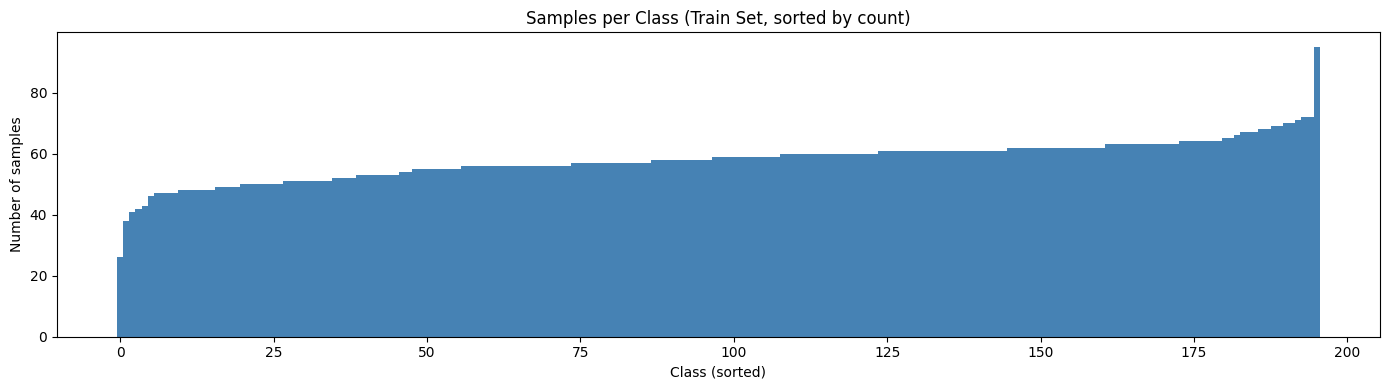

In [9]:
label_counts = Counter(train_ds["label"])
counts = sorted(label_counts.values())

print(f"Samples per class — min: {min(counts)}, max: {max(counts)}, mean: {np.mean(counts):.1f}")

plt.figure(figsize=(14, 4))
plt.bar(range(len(counts)), counts, color="steelblue", width=1.0)
plt.title("Samples per Class (Train Set, sorted by count)")
plt.xlabel("Class (sorted)")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

## 4. Sample Image Grid

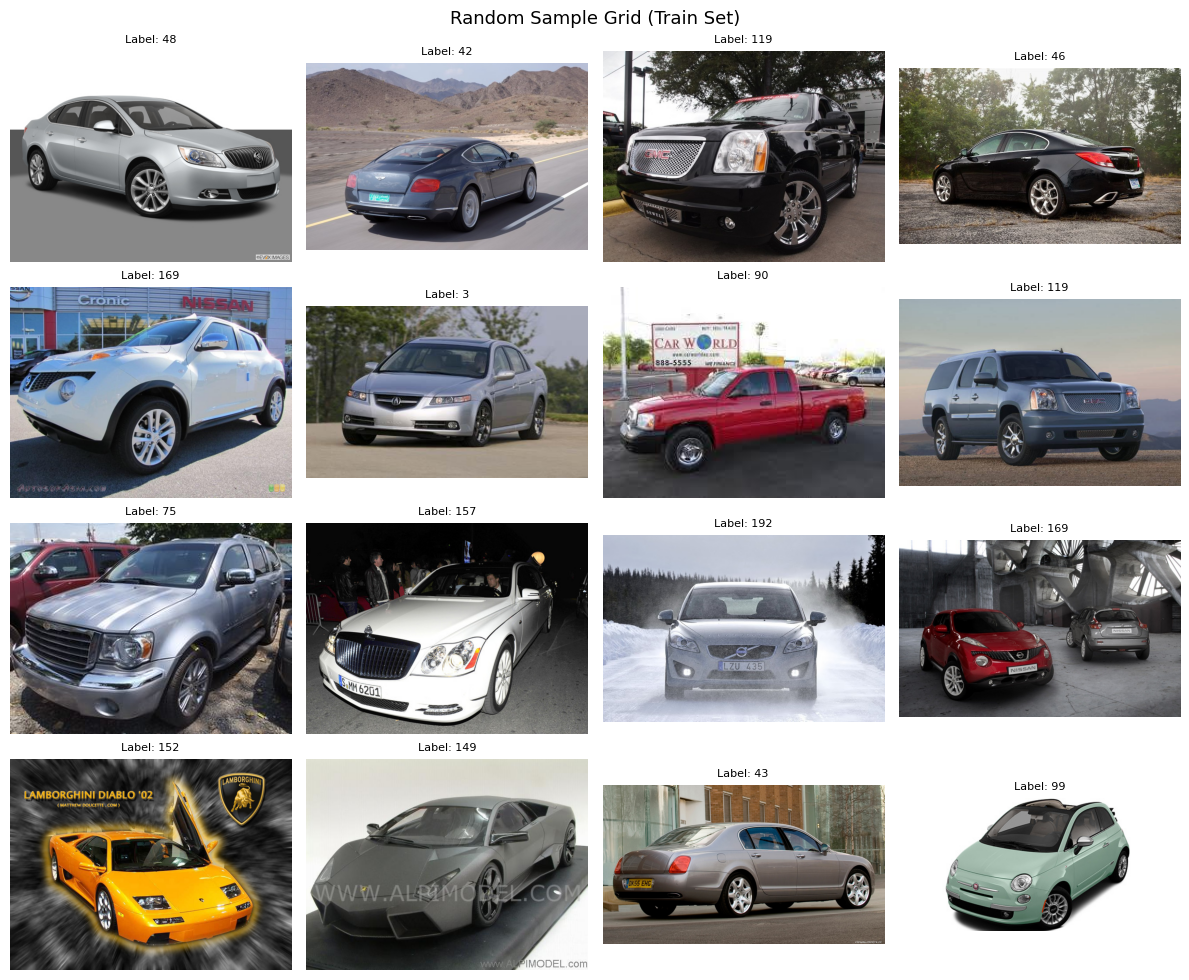

In [10]:
rng = np.random.default_rng(85)
indices = rng.choice(len(train_ds), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 10))
for ax, idx in zip(axes.flat, indices):
    sample = train_ds[int(idx)]
    ax.imshow(sample["image"])
    ax.set_title(f"Label: {sample['label']}", fontsize=8)
    ax.axis("off")
plt.suptitle("Random Sample Grid (Train Set)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Examples per Class (Intra-class Variation)

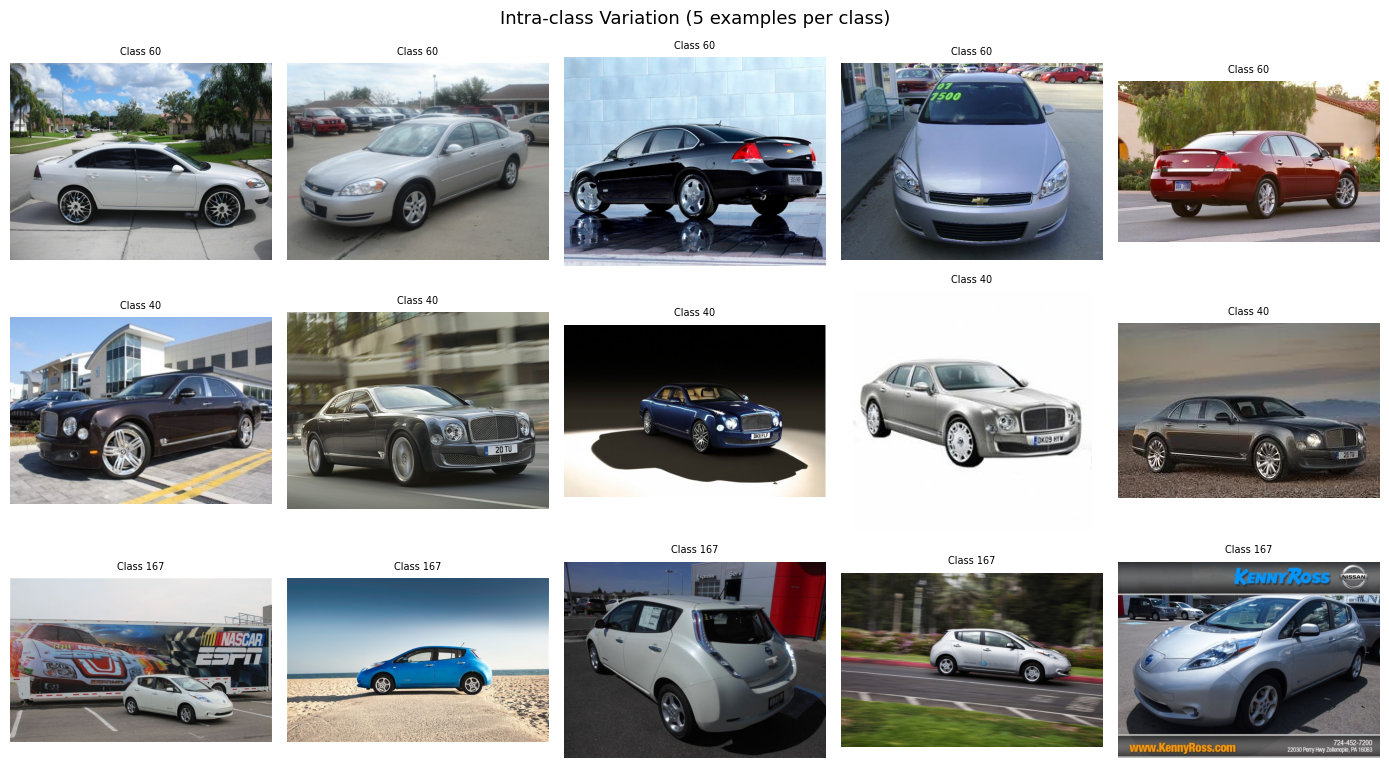

In [11]:
# Pick 3 random classes and show 5 examples each
all_labels = np.array(train_ds["label"])
chosen_classes = rng.choice(list(set(all_labels)), size=3, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for row, cls in enumerate(chosen_classes):
    class_indices = np.where(all_labels == cls)[0]
    picks = rng.choice(class_indices, size=5, replace=False)
    for col, idx in enumerate(picks):
        axes[row, col].imshow(train_ds[int(idx)]["image"])
        axes[row, col].set_title(f"Class {cls}", fontsize=7)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"Class {cls}", fontsize=10)

plt.suptitle("Intra-class Variation (5 examples per class)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. HOG Feature Visualization

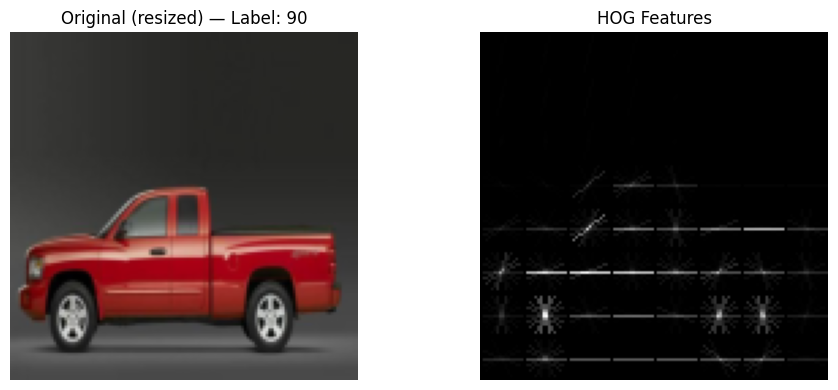

HOG feature vector length: 1764


In [12]:
sample = train_ds[0]
img = np.array(sample["image"])
if img.ndim == 2:
    img = np.stack([img] * 3, axis=-1)
img_resized = resize(img, (128, 128), anti_aliasing=True)
img_gray = rgb2gray(img_resized)

_, hog_img = hog(
    img_gray,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    visualize=True,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_resized)
axes[0].set_title(f"Original (resized) — Label: {sample['label']}")
axes[0].axis("off")
axes[1].imshow(hog_img, cmap="gray")
axes[1].set_title("HOG Features")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"HOG feature vector length: {hog(img_gray, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2)).shape[0]}")